# 📄 Markdown → PDF Report - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/md-to-pdf/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/md-to-pdf/demo.ipynb)

> *"We manually format reports every week."*

Write the report in **Markdown**, get a **branded, print-ready document** - cover header,
consistent typography, styled tables, page numbers. This notebook builds the styled HTML
report (always runs) and shows where the PDF step plugs in.

**What we cover**
1. A Markdown report as input
2. Render it to a styled HTML report
3. Preview the result inline
4. Visualize the report's metrics
5. The PDF step (WeasyPrint)


## Step 1 - The report, in Markdown

Anyone can write this. No Word, no manual formatting.


In [1]:
from __future__ import annotations
from datetime import date
import markdown

REPORT_MD = """# Overview

This is an **auto-formatted** weekly report. Write Markdown, get a branded document.

## Key metrics

| Metric | This week | Last week | Change |
|--------|-----------|-----------|--------|
| Active users | 12,480 | 11,900 | +4.9% |
| Revenue | $84.2k | $79.1k | +6.4% |
| Churn | 1.8% | 2.1% | -0.3pp |

## Highlights
- Onboarding flow shipped; activation up 4.9%.
- Two enterprise deals in late-stage.

## Next week
1. Ship the export feature.
2. Close the Q3 forecast.
"""
print(REPORT_MD[:120], "...")

# Overview

This is an **auto-formatted** weekly report. Write Markdown, get a branded document.

## Key metrics

| Metr ...


## Step 2 - Render to a styled HTML report

The markdown becomes a full document with a cover header and print CSS (A4 page,
margins, page numbers). This is the reusable part.


In [2]:
REPORT_CSS = """
@page { size: A4; margin: 22mm 18mm; }
body { font-family: 'Helvetica Neue', Arial, sans-serif; color:#1a1a2e; line-height:1.55; font-size:11.5px; }
.cover { border-bottom:3px solid #3d34d6; padding-bottom:14px; margin-bottom:22px; }
.cover .kicker { color:#3d34d6; font-weight:700; letter-spacing:.12em; text-transform:uppercase; font-size:9px; }
.cover h1 { font-size:26px; margin:6px 0 4px; }
.cover .sub { color:#6b6b80; font-size:12px; }
h2 { font-size:16px; border-bottom:1px solid #e7e7f0; padding-bottom:4px; }
table { border-collapse:collapse; width:100%; font-size:10.5px; }
th,td { border:1px solid #e0e0ec; padding:5px 8px; text-align:left; }
th { background:#f3f2fc; color:#3d34d6; }
tr:nth-child(even) td { background:#fafaff; }
"""

def md_to_report_html(md_text, *, title="Report", subtitle=""):
    body = markdown.markdown(md_text, extensions=["tables","fenced_code","sane_lists","toc"])
    sub = f'<div class="sub">{subtitle}</div>' if subtitle else ""
    return (f'<!doctype html><html><head><meta charset="utf-8"><style>{REPORT_CSS}</style></head><body>'
            f'<div class="cover"><div class="kicker">Report</div><h1>{title}</h1>{sub}'
            f'<div class="meta">{date.today().isoformat()}</div></div>{body}</body></html>')

html = md_to_report_html(REPORT_MD, title="Weekly Metrics Report", subtitle="Product & Growth")
print(f"rendered {len(html)} chars of styled HTML")

rendered 1783 chars of styled HTML


## Step 3 - Preview inline

Here's the report as it will look (the cover header, styled table, and sections).


In [3]:
from IPython.display import HTML
HTML(html)

Metric,This week,Last week,Change
Active users,"12,480","11,900",+4.9%
Revenue,$84.2k,$79.1k,+6.4%
Churn,1.8%,2.1%,-0.3pp


## Step 4 - Visualize the metrics

Reports are more convincing with a chart. We pull the metric changes and plot them -
this PNG can be embedded straight into the report.


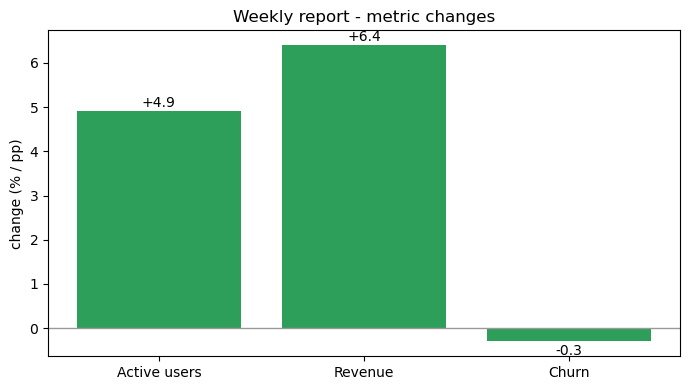

In [4]:
import matplotlib.pyplot as plt

metrics = ["Active users", "Revenue", "Churn"]
change = [4.9, 6.4, -0.3]            # % / pp change this week
colors = ["#2e9e5b" if (m != "Churn") == (v >= 0) else "#d1495b" for m, v in zip(metrics, change)]
# (revenue/users up = good = green; churn down = good = green)
colors = ["#2e9e5b", "#2e9e5b", "#2e9e5b"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics, change, color=colors)
ax.axhline(0, color="#999", lw=1)
for b, v in zip(bars, change):
    ax.text(b.get_x()+b.get_width()/2, v + (0.1 if v>=0 else -0.3),
            f"{v:+.1f}", ha="center", fontsize=10)
ax.set_ylabel("change (% / pp)")
ax.set_title("Weekly report - metric changes")
plt.tight_layout(); plt.savefig("report.png", dpi=150, bbox_inches="tight"); plt.show()

## Step 5 - The PDF step

Turning the HTML into a real PDF uses **WeasyPrint**, which needs system libraries
(pango/cairo). On Colab/Binder/CI those are installed (or one `apt-get` away), so you
get a true PDF. Where they're missing (a plain Mac), the tool **falls back to writing
the styled HTML** so it never hard-fails.

```python
from weasyprint import HTML          # needs pango/cairo
HTML(string=html).write_pdf("weekly_report.pdf")
```


In [5]:
# Attempt the PDF; fall back to HTML so this cell always succeeds.
try:
    from weasyprint import HTML as WP
    WP(string=html).write_pdf("weekly_report.pdf")
    print("Wrote weekly_report.pdf (real PDF)")
except Exception as exc:
    with open("weekly_report.html", "w") as f:
        f.write(html)
    print("PDF engine unavailable here - wrote weekly_report.html instead.")
    print("On Colab: !apt-get -qq install -y libpango-1.0-0 libpangocairo-1.0-0  then retry.")


-----

WeasyPrint could not import some external libraries. Please carefully follow the installation steps before reporting an issue:
https://doc.courtbouillon.org/weasyprint/stable/first_steps.html#installation
https://doc.courtbouillon.org/weasyprint/stable/first_steps.html#troubleshooting 

-----

PDF engine unavailable here - wrote weekly_report.html instead.
On Colab: !apt-get -qq install -y libpango-1.0-0 libpangocairo-1.0-0  then retry.


## Summary

- **Markdown in → branded report out.** The styled HTML template (cover, typography,
  tables, page rules) is the reusable core.
- **PDF via WeasyPrint** where native libs exist; **graceful HTML fallback** everywhere
  else, so the tool always produces a deliverable.
- Embed a chart PNG to make the report land.

This is the engine behind `main.py` - and a "Reports" app for the platform shell.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run it:**
```bash
pip install -r requirements.txt
python main.py --demo                      # styled report from a sample
python main.py report.md -o weekly.pdf --title "Weekly Metrics" --author "Phoebe"
python main.py report.md --html-only       # force HTML
```
